# 03 — Context preservation, on vs off (RQ3)

**Headline (behaviour):** an oculomotor disruption proxy — the regression rate — computed identically from the gaze stream with and without preservation.

**Mechanism (and its limitation):** within the *with* runs the reader records, per intervention, the displacement the reflow induced (`viewportDeltaPx`) and the residual after the restore (`anchorErrorPx`), plus a graded outcome. All interventions in this dataset are font-size changes (layout-changing → *semantic-restart*).

N=2: descriptive, not inferential.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _lib
_lib.apply_style()
try:
    data = _lib.read_cache()
except FileNotFoundError:
    data = _lib.load_all(); _lib.write_cache(data)


## 1 — Behaviour: regression rate, with vs without (headline)
A backward saccade (regression) is a standard oculomotor sign of reading disruption.

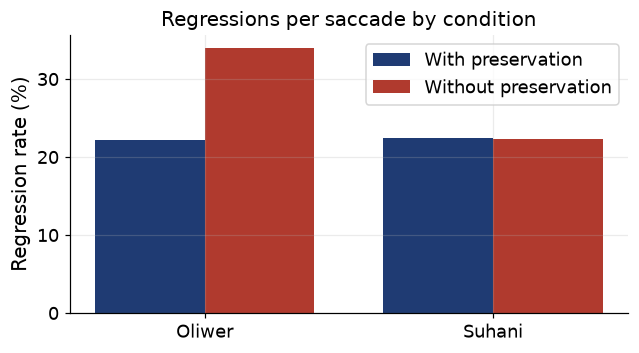

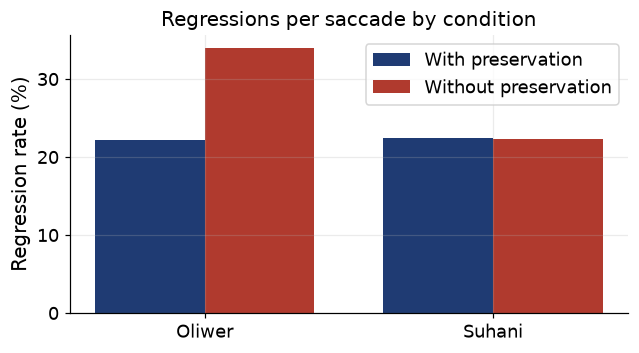

In [2]:
reg = data.saccades.groupby(['participant','condition'])['isRegression'].mean().unstack('condition')
reg = reg.reindex(columns=[c for c in _lib.CONDITION_ORDER if c in reg.columns])
_lib.save_table((reg*100).round(1).reset_index(), 'regression_rate_by_condition')
parts = list(reg.index); x = np.arange(len(parts)); w = 0.38
fig, ax = plt.subplots(figsize=(6, 3.4))
for i, cond in enumerate([c for c in _lib.CONDITION_ORDER if c in reg.columns]):
    ax.bar(x + (i-0.5)*w, reg[cond]*100, w, label=_lib.CONDITION_LABELS[cond], color=_lib.CONDITION_COLORS[cond])
ax.set_xticks(x); ax.set_xticklabels(parts); ax.set_ylabel('Regression rate (%)')
ax.set_title('Regressions per saccade by condition'); ax.legend()
fig.tight_layout(); _lib.save_fig(fig, '03_regression_rate'); fig

In [3]:
# Pooled direction of effect (descriptive).
pooled = data.saccades.groupby('condition')['isRegression'].mean().mul(100).round(1)
pooled.to_frame('regression_rate_pct')

,regression_rate_pct
condition,
with,22.4
without,31.1


## 2 — Mechanism and its limitation
The restore runs and is fully audited, but the outcome is mostly graded *degraded*. The reason is informative rather than a recording failure: the reader's reading position drifted only a little (`viewportDeltaPx`), yet the semantic-restart strategy repositions the committed sentence to its target, so the residual (`anchorErrorPx`) *exceeds* the induced displacement. For small font-size reflows the restore is over-aggressive — a limitation we return to as future work (a gentler, Kalman-filter-style stabilisation, or keeping the reader's exact offset for small changes).

In [4]:
cp = data.context_preservation.copy()
iv = data.interventions[['sessionKey','appliedAtUnixMs','affectedProperties','restoreMode','fontSizePx']]
cp = cp.sort_values('interventionAppliedAtUnixMs')
iv = iv.sort_values('appliedAtUnixMs')
cp = pd.merge_asof(cp, iv, left_on='interventionAppliedAtUnixMs', right_on='appliedAtUnixMs',
                   by='sessionKey', direction='nearest', tolerance=2000)
outcome = cp.groupby('status').agg(n=('status','size'),
    median_anchorErrorPx=('anchorErrorPx','median'),
    median_viewportDeltaPx=('viewportDeltaPx','median')).reset_index()
_lib.save_table(cp, 'context_preservation_events')
_lib.save_table(outcome, 'context_preservation_outcomes')
outcome.round(2)

,status,n,median_anchorErrorPx,median_viewportDeltaPx
0,degraded,7,396.50,39.00
1,preserved,2,0.02,25.48


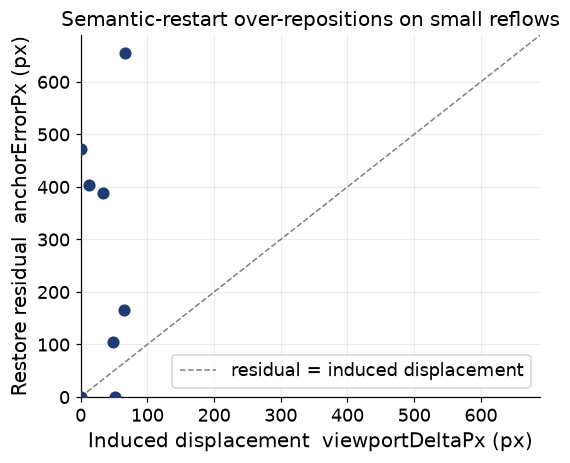

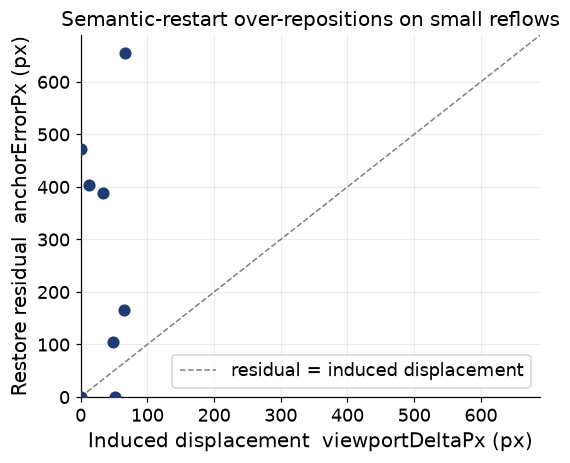

In [5]:
# Honest limitation figure: restore residual vs the displacement actually induced.
# Points above the dashed line mean the restore moved the reader MORE than the reflow did.
ev = cp.reset_index(drop=True).copy()
m = ev['anchorErrorPx'].notna() & ev['viewportDeltaPx'].notna()
ev = ev[m]
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(ev['viewportDeltaPx'], ev['anchorErrorPx'], s=48, zorder=3,
           color=_lib.CONDITION_COLORS['with'])
lim = float(max(ev['viewportDeltaPx'].max(), ev['anchorErrorPx'].max())) * 1.05 + 1
ax.plot([0, lim], [0, lim], ls='--', c='gray', lw=1, label='residual = induced displacement')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Induced displacement  viewportDeltaPx (px)')
ax.set_ylabel('Restore residual  anchorErrorPx (px)')
ax.set_title('Semantic-restart over-repositions on small reflows')
ax.legend(loc='lower right')
fig.tight_layout(); _lib.save_fig(fig, '03_restore_overreposition'); fig